## Get Data

In [1]:
import os
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
from utils8 import AudioCNN
from utils8.data import AudioDataset2, TransformedSubset, get_dataloader
from utils8.augmentations import *
from torchvision.transforms import v2

# Get Data
path = os.path.join('Data', 'Digits')
classes = ['zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine']
dataset = AudioDataset2(path, classes=classes)

# Data Split and Subsets
idx = list(range(len(dataset)))
labels = dataset.labels

train_transforms = v2.Compose([
    AudioPitchShift(n_steps=3.0, sr=8000),
    AudioGaussianNoise(snr_db=torch.tensor([20])),
    AudioReverb(sr=8000, room_scale=0.25)
])
train_val_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=labels, random_state=42)

train_val_set = Subset(dataset, train_val_idx)
test_set = Subset(dataset, test_idx)

## Get Optuna Params

In [2]:
import pandas as pd

studies = sorted(os.listdir('optuna_results'))

print('Available studies: ')
for s in studies:
    s = s.replace('(', '_')
    s = s.replace(')', '_')
    parsed_s = s.split('_')
    print(f'{parsed_s[1]}/{parsed_s[2]}/{parsed_s[3]} - {parsed_s[4]}')

last_study_path = os.path.join('optuna_results', studies[-1])
last_study = pd.read_csv(last_study_path)

study = last_study.iloc[0].to_dict()

network_col = ["params_dropout_rate", "params_lr", "params_patience", "params_weight_decay"]
best_params = {}
for col in network_col:
    best_params[col.removeprefix('params_')] = study[col]

best_params

Available studies: 
20/05/2026 - 12:08


{'dropout_rate': 0.0082966517228649,
 'lr': 0.0016068082173041,
 'patience': 5,
 'weight_decay': 0.0001426599145501}

## Training

In [3]:
import os
from sklearn.model_selection import KFold
from torch.utils.tensorboard import SummaryWriter
from torch import nn,optim
from utils8.dir_managment import clean_dir
from utils8.AudioCNN import AudioCNN
from utils8.training import train_one_fold, get_train_loaders_with_transforms, save_model_dict, save_target_labels


model_name = 'model_3'

log_dir = os.path.join('runs', 'training', model_name)
clean_dir(log_dir)
os.makedirs(log_dir, exist_ok=True)
writer = SummaryWriter(log_dir=log_dir)

save_model_dir = os.path.join('Models', model_name)
clean_dir(save_model_dir)
os.makedirs(save_model_dir, exist_ok=True)

model_params = {'dropout_rate': best_params['dropout_rate'], 'num_classes': 10}
save_model_dict(model_params, save_model_dir)
save_target_labels(classes, save_model_dir)

N_EPOCHS = 35
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(train_val_set)):
    print(f'\n ===================== Training Fold {fold}  ===================== \n')
    # Loaders
    train_loader, val_loader = get_train_loaders_with_transforms(train_val_set, train_idx,val_idx , transform=train_transforms, batch_size=32)


    # Model, Optimizer, Criterion
    criterion = nn.CrossEntropyLoss()
    model =  AudioCNN(dropout_rate=best_params['dropout_rate'])
    optimizer = optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=best_params['patience'])

    # Fold Training
    loss = train_one_fold(fold, model, train_loader, val_loader, optimizer, scheduler, criterion, n_epochs=N_EPOCHS, write_model_dir=save_model_dir, writer=writer)




Cleaning existing files at runs/training/model_3...
Cleaning existing files at Models/model_3...
Model dict saved in Models/model_3/model_dict.json
Labels dict saved in Models/model_3/data_labels.json

 ===================== Training Fold 0  ===================== 

Saved new best model to Models/model_3/fold_0.pth, with new best_val_loss=1.8830942897884935
Saved new best model to Models/model_3/fold_0.pth, with new best_val_loss=1.7737736768192716
Saved new best model to Models/model_3/fold_0.pth, with new best_val_loss=1.717846636418943
Saved new best model to Models/model_3/fold_0.pth, with new best_val_loss=1.53349675182943
Saved new best model to Models/model_3/fold_0.pth, with new best_val_loss=1.228936462490647
Saved new best model to Models/model_3/fold_0.pth, with new best_val_loss=1.0819038064391524
Saved new best model to Models/model_3/fold_0.pth, with new best_val_loss=0.7854006610534809
Saved new best model to Models/model_3/fold_0.pth, with new best_val_loss=0.76486800417

In [ ]:
#  tensorboard --logdir Lab8/runs/training/model_3

# Evaluation and Testing

In [4]:
import os
from utils8.Predictor import Predictor

model_path = os.path.join('Models', 'model_3')
predictor_obj = Predictor(model_path)

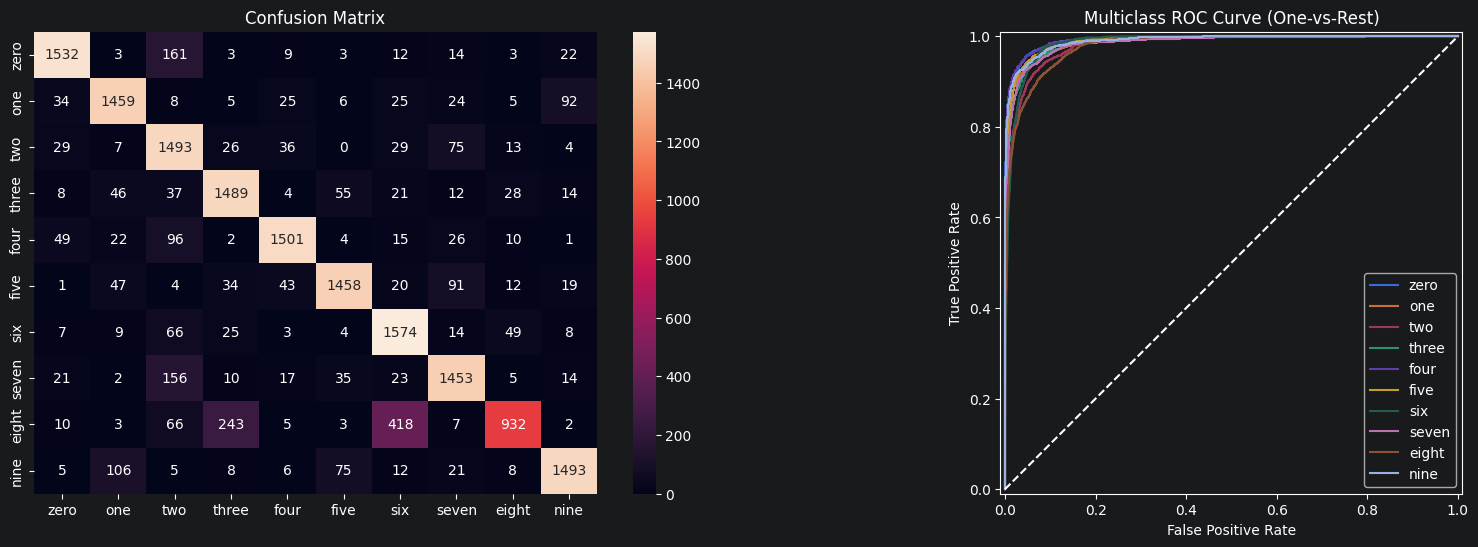

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      1762
           1       0.86      0.87      0.86      1683
           2       0.71      0.87      0.78      1712
           3       0.81      0.87      0.84      1714
           4       0.91      0.87      0.89      1726
           5       0.89      0.84      0.86      1729
           6       0.73      0.89      0.81      1759
           7       0.84      0.84      0.84      1736
           8       0.88      0.55      0.68      1689
           9       0.89      0.86      0.88      1739

    accuracy                           0.83     17249
   macro avg       0.84      0.83      0.83     17249
weighted avg       0.84      0.83      0.83     17249



In [5]:
# Train data Classification report
predictor_obj.metric_report(data=Subset(dataset, train_val_idx))

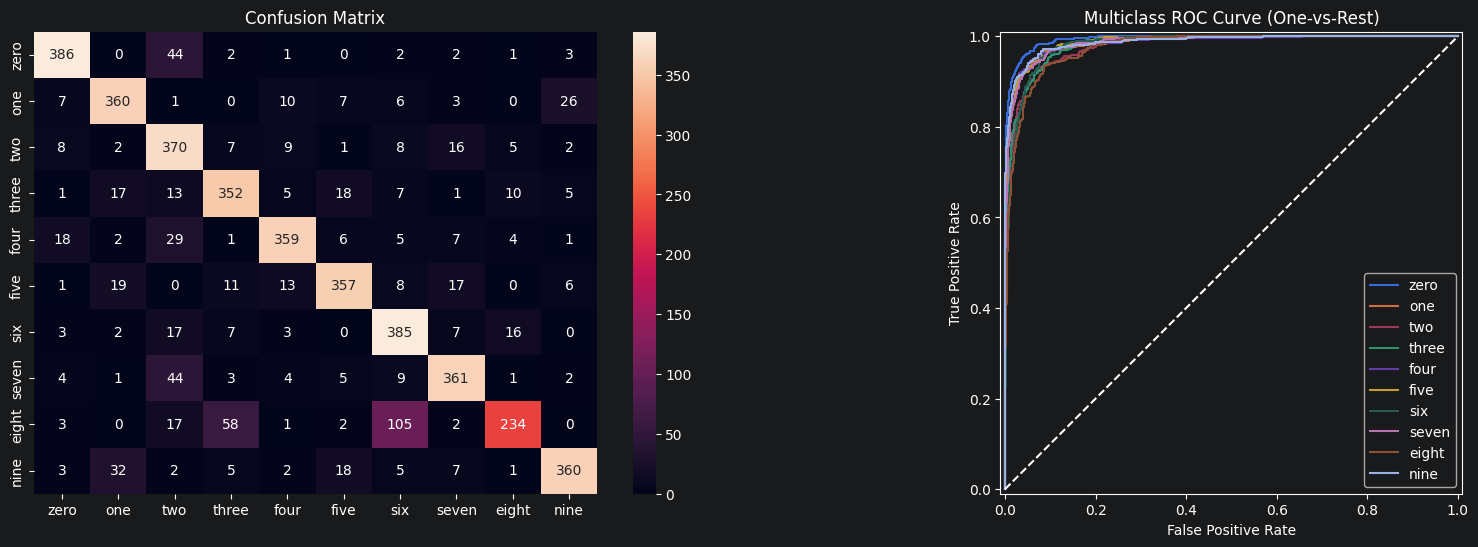

              precision    recall  f1-score   support

           0       0.89      0.88      0.88       441
           1       0.83      0.86      0.84       420
           2       0.69      0.86      0.77       428
           3       0.79      0.82      0.80       429
           4       0.88      0.83      0.86       432
           5       0.86      0.83      0.84       432
           6       0.71      0.88      0.79       440
           7       0.85      0.83      0.84       434
           8       0.86      0.55      0.67       422
           9       0.89      0.83      0.86       435

    accuracy                           0.82      4313
   macro avg       0.83      0.82      0.82      4313
weighted avg       0.83      0.82      0.82      4313



In [6]:
# Test data Classification report
predictor_obj.metric_report(data=Subset(dataset, test_idx))

## Testing Ensembles

In [7]:
import numpy as np
from statsmodels.stats.contingency_tables import mcnemar
from utils8.Predictor import Predictor

model_scratch_path = os.path.join('Models', 'model_2')
pred_s = Predictor(model_scratch_path)

model_finetuned_path = os.path.join('Models', 'model_3')
pred_f = Predictor(model_finetuned_path)

# 1. Dummy Data: True labels and predictions from 2 ensemble models
# Let's assume 0 = Incorrect, 1 = Correct prediction for a test set
true_labels = [label for _, label in test_set]


# Simulate predictions
models_preds = pred_s.predict(test_set)
modelf_preds = pred_f.predict(test_set)

# 2. Calculate the outcomes (Correct vs Incorrect)
ms_correct = (models_preds == true_labels)
mf_correct = (modelf_preds == true_labels)

# 3. Build the 2x2 Contingency Table
# True/True, True/False, False/True, False/False
a = np.sum(ms_correct & mf_correct)
b = np.sum(ms_correct & ~mf_correct)
c = np.sum(~ms_correct & mf_correct)
d = np.sum(~ms_correct & ~mf_correct)

table = [[a, b],
         [c, d]]

print("Contingency Table:")
print(f"[{a}, {b}]")
print(f"[{c}, {d}]\n")

# 4. Perform McNemar's Test
# exact=False uses the Chi-Squared distribution (good for large samples)
# correction=True applies Edwards' continuity correction
result = mcnemar(table, exact=False, correction=True)

# 5. Interpret Results
print(f"Statistic: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4e}")

alpha = 0.05
if result.pvalue < alpha:
    print("Conclusion: Reject the null hypothesis. There is a statistically significant difference between the two ensemble models.")
else:
    print("Conclusion: Fail to reject the null hypothesis. There is no statistically significant difference between the two ensemble models.")

Contingency Table:
[3457, 603]
[67, 186]

Statistic: 427.2015
P-value: 6.6067e-95
Conclusion: Reject the null hypothesis. There is a statistically significant difference between the two ensemble models.
